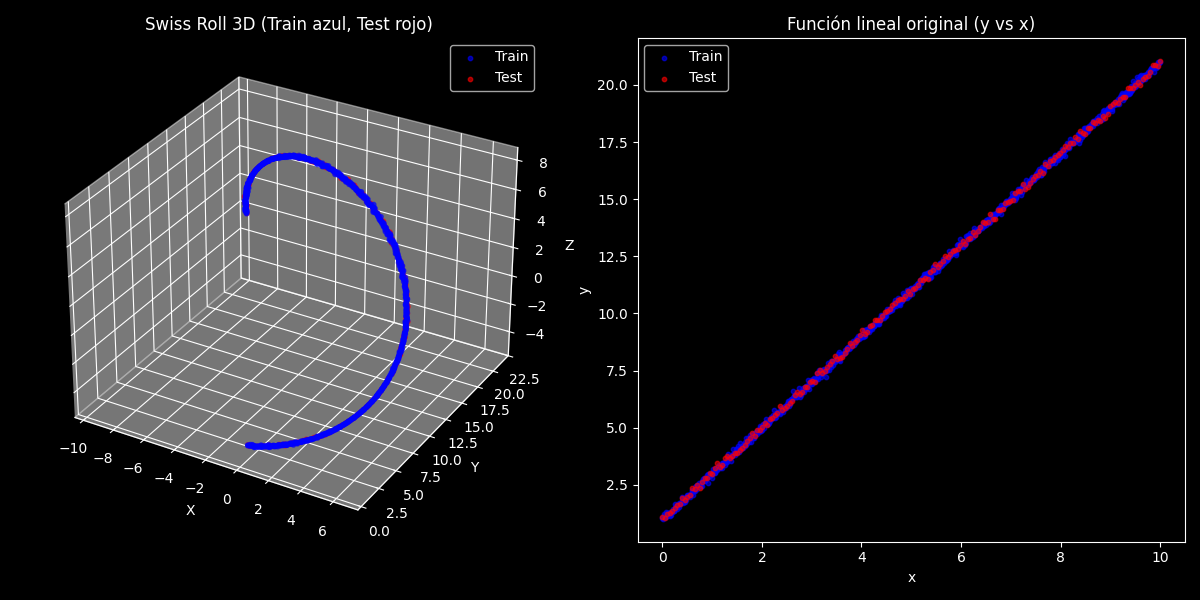

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib ipympl

def generar_swiss_roll_lineal_dataset(n_train=800, n_test=200, ruido=0.1, random_seed=42):
    np.random.seed(random_seed)

    def crear_datos(n):
        x = np.linspace(0, 10, n)
        y = 2 * x + 1 + np.random.normal(0, ruido, n)
        t = 1.5 * np.pi * (1 + x / 10)
        X_swiss = t * np.cos(t)
        Y_swiss = y
        Z_swiss = t * np.sin(t)
        X = np.vstack([X_swiss, Y_swiss, Z_swiss]).T
        return X, y, x

    X_train, y_train, x_train = crear_datos(n_train)
    X_test, y_test, x_test = crear_datos(n_test)

    return X_train, y_train, x_train, X_test, y_test, x_test

X_train, y_train, x_train, X_test, y_test, x_test = generar_swiss_roll_lineal_dataset()

# Plot Swiss Roll 3D train y test juntos
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c='blue', label='Train', s=10, alpha=0.6)
ax.scatter(X_test[:,0], X_test[:,1], X_test[:,2], c='red', label='Test', s=10, alpha=0.6)
ax.set_title("Swiss Roll 3D (Train azul, Test rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

# Plot función lineal original (y vs x)
ax2 = fig.add_subplot(122)
ax2.scatter(x_train, y_train, c='blue', label='Train', s=10, alpha=0.6)
ax2.scatter(x_test, y_test, c='red', label='Test', s=10, alpha=0.6)
ax2.set_title("Función lineal original (y vs x)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()

plt.tight_layout()
plt.show()

In [3]:
# Center
X_train -= np.mean(X_train, axis=0)
# Calculate covariance eigenvectors
cov = (X_train.T @ X_train) / X_train.shape[0]
eigvals, eigvecs = np.linalg.eigh(cov)

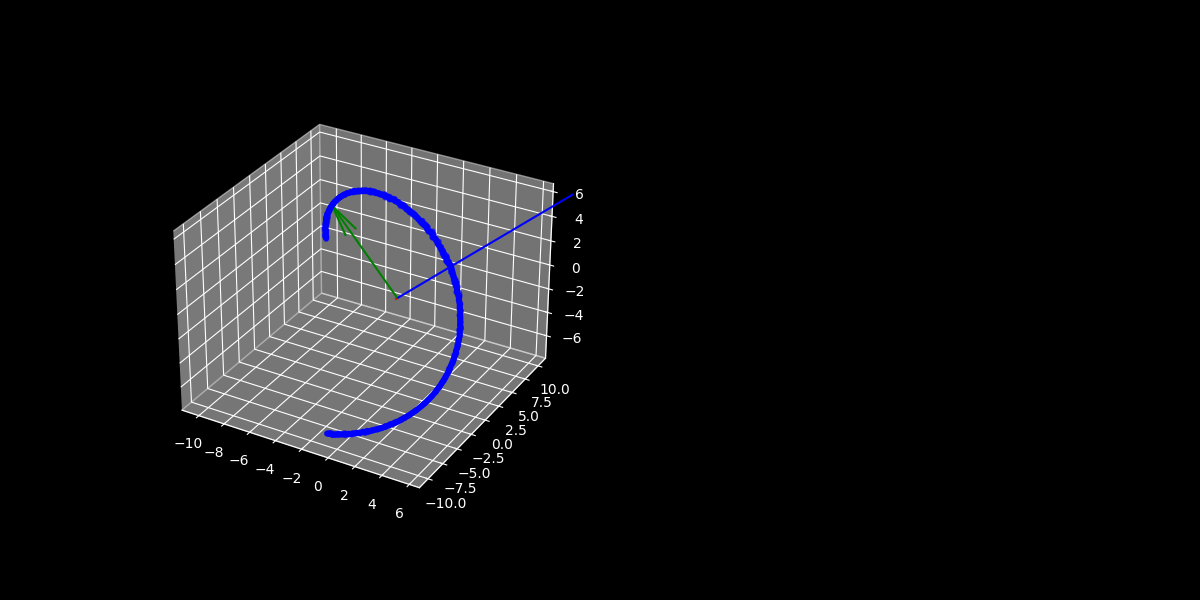

In [6]:
# Show
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c='blue', label='Train', s=10, alpha=0.6)
for i in range(eigvecs.shape[0]):
    v = eigvecs[i, :] * (eigvals[i] / 2)
    ax.quiver(0, 0, 0, v[0], v[1], v[2], color=["red", "green", "blue"][i])

plt.show()

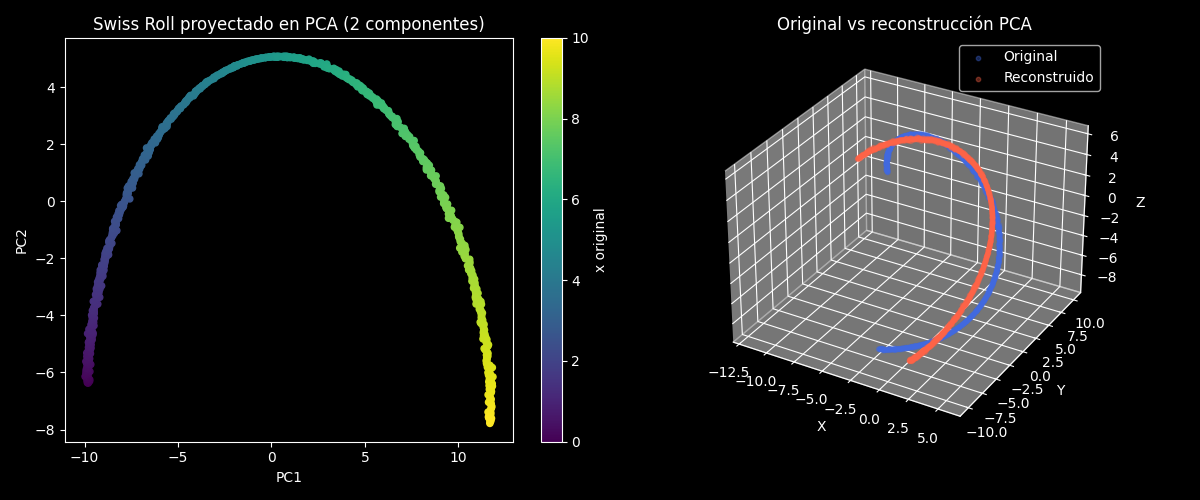

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
X_recon = pca.inverse_transform(X_pca)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121)
sc = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=x_train, s=20, cmap="viridis")
ax1.set_title("Swiss Roll proyectado en PCA (2 componentes)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
plt.colorbar(sc, ax=ax1, label="x original")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c="royalblue", s=10, alpha=0.35, label="Original")
ax2.scatter(X_recon[:, 0], X_recon[:, 1], X_recon[:, 2], c="tomato", s=10, alpha=0.35, label="Reconstruido")
ax2.set_title("Original vs reconstrucción PCA")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.legend()

plt.tight_layout()
plt.show()